In [1]:
!pip install itk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 22.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 26.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 62.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 56.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 80.0 MB/s eta 0:00:00:00:0100:01


In [2]:
# Install dependencies needed for medical imaging
!pip install -q --upgrade monai nibabel itk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.4 MB/s eta 0:00:00:00:01


In [3]:
import os
import glob

# Find the image and label directories
img_dir = None
lbl_dir = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'imagesTr' in dirs:
        img_dir = os.path.join(root, 'imagesTr')
    if 'labelsTr' in dirs:
        lbl_dir = os.path.join(root, 'labelsTr')

if not img_dir or not lbl_dir:
    print("Error: Could not find imagesTr or labelsTr folders")
else:
    print(f"Found Images at: {img_dir}")
    print(f"Found Labels at: {lbl_dir}")

# Match the .mha files
images = sorted(glob.glob(os.path.join(img_dir, "*.mha")))
labels = sorted(glob.glob(os.path.join(lbl_dir, "*.mha")))

data_dicts = []
for img in images:
    file_id = os.path.basename(img).replace("_0000.mha", "")
    expected_label = os.path.join(lbl_dir, f"{file_id}.mha")
    
    if os.path.exists(expected_label):
        data_dicts.append({"image": img, "label": expected_label})

if len(data_dicts) > 0:
    train_files = data_dicts[:65]
    val_files = data_dicts[65:75]
    test_files = data_dicts[75:]
    print(f"Total Pairs: {len(data_dicts)}")
    print(f"Sample Image: {os.path.basename(data_dicts[0]['image'])}")
    print(f"Sample Label: {os.path.basename(data_dicts[0]['label'])}")
else:
    print("Found folders, but filenames didn't match")

Found Images at: /kaggle/input/datasets/praveenkoushikmuvva/cbct-scan/CBCT/imagesTr
Found Labels at: /kaggle/input/datasets/praveenkoushikmuvva/cbct-scan/CBCT/labelsTr
Total Pairs: 82
Sample Image: ToothFairy2F_001_0000.mha
Sample Label: ToothFairy2F_001.mha


In [4]:
# Check the split distribution
print(f"Training: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Training: 65 | Val: 10 | Test: 7


In [5]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, 
    Spacingd, ScaleIntensityRanged, CropForegroundd, 
    RandSpatialCropd, SpatialPadd, EnsureTyped,
    RandFlipd, RandRotate90d, RandGaussianNoised, RandShiftIntensityd
)

# Preprocessing and augmentation for training
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(0.5, 0.5, 0.5), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1500, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"], spatial_size=[128, 128, 128]),
    RandSpatialCropd(keys=["image", "label"], roi_size=[128, 128, 128], random_center=True),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    RandGaussianNoised(keys=["image"], prob=0.1, mean=0.0, std=0.1),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    EnsureTyped(keys=["image", "label"]),
])

# Same preprocessing for validation but without augmentation
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(0.5, 0.5, 0.5), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1500, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"], spatial_size=[128, 128, 128]),
    EnsureTyped(keys=["image", "label"]),
])

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-07 15:37:08.819493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775576229.040455      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775576229.111841      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775576229.623705      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775576229.623746      55 computation_placer.cc:1

In [6]:
# Import dataloader utilities
from monai.data import PersistentDataset, DataLoader

In [7]:
import os
from monai.data import PersistentDataset, DataLoader

# Create data loaders with caching to speed up training
cache_dir = "/kaggle/working/monai_cache"
os.makedirs(cache_dir, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2)

val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=2)

print(f"DataLoaders ready. Cache stored at: {cache_dir}")

DataLoaders ready. Cache stored at: /kaggle/working/monai_cache


In [8]:
# For visualization
import matplotlib.pyplot as plt

Shape: torch.Size([512, 512, 262])


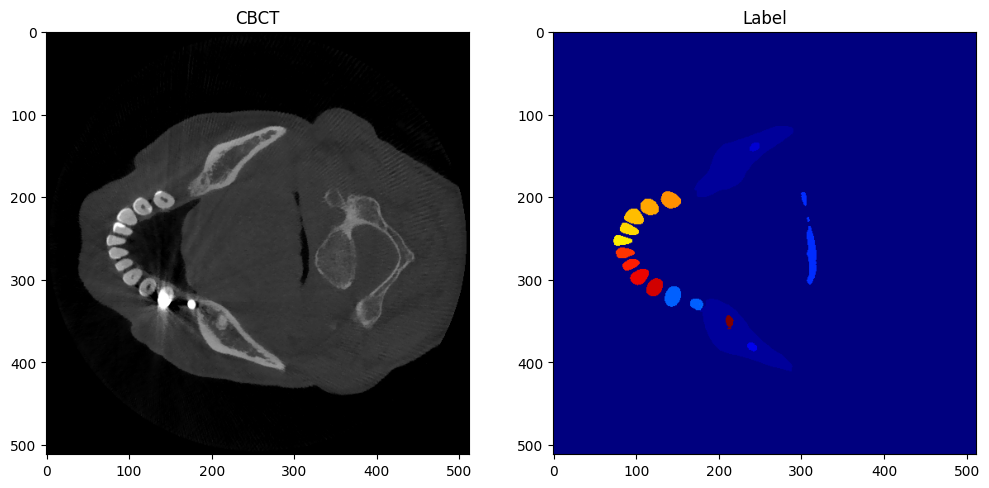

In [9]:
import nibabel as nib
from monai.transforms import LoadImage
import matplotlib.pyplot as plt

# Load and visualize a sample image and its label
loader = LoadImage(image_only=True)
test_img = loader(train_files[0]['image'])
test_lbl = loader(train_files[0]['label'])

print(f"Shape: {test_img.shape}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(test_img[:, :, test_img.shape[2]//2], cmap='gray')
plt.title("CBCT")
plt.subplot(1, 2, 2)
plt.imshow(test_lbl[:, :, test_lbl.shape[2]//2], cmap='jet')
plt.title("Label")
plt.show()

In [10]:
import torch
from monai.networks.nets import UNet
from monai.losses import DiceCELoss

# Build the 3D UNet model
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=43,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"Model initialized on {device}")

Model initialized on cuda


In [11]:
# Train the model
max_epochs = 100
print("Training started...")

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        if labels.max() >= 43:
            print(f"Warning: Found label {labels.max().item()}")
            labels[labels >= 43] = 0

        optimizer.zero_grad()
        outputs = model(inputs)
        
        try:
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        except Exception as e:
            print(f"Error at batch {step}: {e}")
            break
            
    print(f"Epoch {epoch+1} Loss: {epoch_loss/step:.4f}")

Training started...
Epoch 1 Loss: 4.0270
Epoch 2 Loss: 2.2750
Epoch 3 Loss: 1.5296
Epoch 4 Loss: 1.3466
Epoch 5 Loss: 1.2747
Epoch 6 Loss: 1.2304
Epoch 7 Loss: 1.2042
Epoch 8 Loss: 1.1718
Epoch 9 Loss: 1.1741
Epoch 10 Loss: 1.1444
Epoch 11 Loss: 1.1564
Epoch 12 Loss: 1.1378
Epoch 13 Loss: 1.1305
Epoch 14 Loss: 1.1094
Epoch 15 Loss: 1.1400
Epoch 16 Loss: 1.1184
Epoch 17 Loss: 1.0979
Epoch 18 Loss: 1.0950
Epoch 19 Loss: 1.1062
Epoch 20 Loss: 1.0902
Epoch 21 Loss: 1.0870
Epoch 22 Loss: 1.0935
Epoch 23 Loss: 1.0861
Epoch 24 Loss: 1.0986
Epoch 25 Loss: 1.0817
Epoch 26 Loss: 1.0697
Epoch 27 Loss: 1.0707
Epoch 28 Loss: 1.0741
Epoch 29 Loss: 1.0650
Epoch 30 Loss: 1.0668
Epoch 31 Loss: 1.0584
Epoch 32 Loss: 1.0601
Epoch 33 Loss: 1.0623
Epoch 34 Loss: 1.0601
Epoch 35 Loss: 1.0582
Epoch 36 Loss: 1.0467
Epoch 37 Loss: 1.0481
Epoch 38 Loss: 1.0478
Epoch 39 Loss: 1.0369
Epoch 40 Loss: 1.0294
Epoch 41 Loss: 1.0366
Epoch 42 Loss: 1.0428
Epoch 43 Loss: 1.0412
Epoch 44 Loss: 1.0335
Epoch 45 Loss: 1.0350

In [12]:
import os
import torch

# Save the trained model
save_path = "/kaggle/working/dental_unet_final.pth"
torch.save(model.state_dict(), save_path)

if os.path.exists(save_path):
    print(f"Model saved at: {save_path}")
else:
    print("Save failed")

Model saved at: /kaggle/working/dental_unet_final.pth


In [13]:
# Check what files we have
import os
print(os.listdir("/kaggle/working"))

['dental_unet_final.pth', 'monai_cache', '.virtual_documents']


In [14]:
from monai.inferers import sliding_window_inference
import nibabel as nib
import torch
import numpy as np

# Run inference on a validation sample
model.eval()
test_data = val_ds[0] 
test_input = test_data["image"].unsqueeze(0).to(device)

print("Running inference...")

with torch.no_grad():
    output = sliding_window_inference(test_input, (128, 128, 128), 4, model)
    prediction = torch.argmax(output, dim=1).detach().cpu().numpy()[0]

try:
    affine = test_data["image"].affine.numpy()
except AttributeError:
    affine = np.eye(4)

scan_array = test_data["image"][0].detach().cpu().numpy()

# Save as NIfTI format for 3D visualization
nib.save(nib.Nifti1Image(scan_array, affine), "/kaggle/working/scan.nii.gz")
nib.save(nib.Nifti1Image(prediction.astype(np.uint8), affine), "/kaggle/working/mask.nii.gz")

print("Inference complete")

Running inference...


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


Inference complete


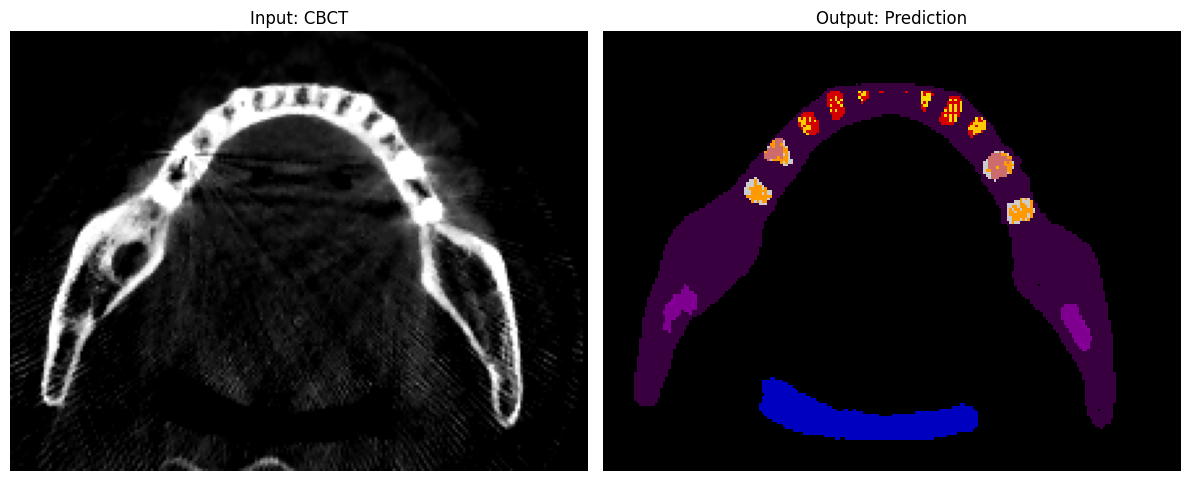

In [15]:
import matplotlib.pyplot as plt

# Visualize the prediction at the middle slice
mid_slice = scan_array.shape[2] // 2

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Input: CBCT")
plt.imshow(scan_array[:, :, mid_slice].T, cmap="gray", origin="lower")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Output: Prediction")
plt.imshow(prediction[:, :, mid_slice].T, cmap="nipy_spectral", interpolation="nearest", origin="lower")
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
import os
import zipfile
from IPython.display import display, HTML

# Package everything together for download
files_to_save = [
    '/kaggle/working/dental_unet_final.pth',
    '/kaggle/working/mask.nii.gz',
    '/kaggle/working/scan.nii.gz'
]

zip_name = 'Startup_Demo_Assets.zip'

print("Packaging files...")

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_save:
        if os.path.exists(file_path):
            zipf.write(file_path, os.path.basename(file_path))
            print(f"Added {os.path.basename(file_path)}")
        else:
            print(f"Warning: Could not find {file_path}")

print("Done")

download_html = f"""
<div style="padding: 20px; background-color: #e6f7ff; border-left: 6px solid #0078D4; border-radius: 5px; margin-top: 10px;">
    <h2 style="margin: 0; color: #003366;">Files Ready</h2>
    <p style="font-size: 16px;">Download your files:</p>
    <a href="./{zip_name}" target="_blank" style="font-size: 20px; font-weight: bold; color: #0078D4; text-decoration: none;">
        Download {zip_name}
    </a>
</div>
"""
display(HTML(download_html))

Packaging files...
Added dental_unet_final.pth
Added mask.nii.gz
Added scan.nii.gz
Done
